## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

In [ ]:
def simulazione_lanci(N):
    lanci=[np.random.randint(0,2) for i in range(N)]
    return (sum(lanci)/N)*100

In [ ]:
def funzione (vec_prob, n):
    campione = np.random.choice(a=[0,1], size=n, replace=True, p=vec_prob)
    return sum(campione)

In [3]:
def simulazione_lanci(N):
    lanci=[rd.randint(0,1) for i in range(N)]
    return (sum(lanci)/N)*100
campioni=[n for n in range(10,20001, int(20000/100))]
risultati_campioni=[simulazione_lanci(n) for n in campioni]
ls_risultati=[[campioni[i],risultati_campioni[i]] for i in range(len(campioni))]
df=pd.DataFrame(ls_risultati)


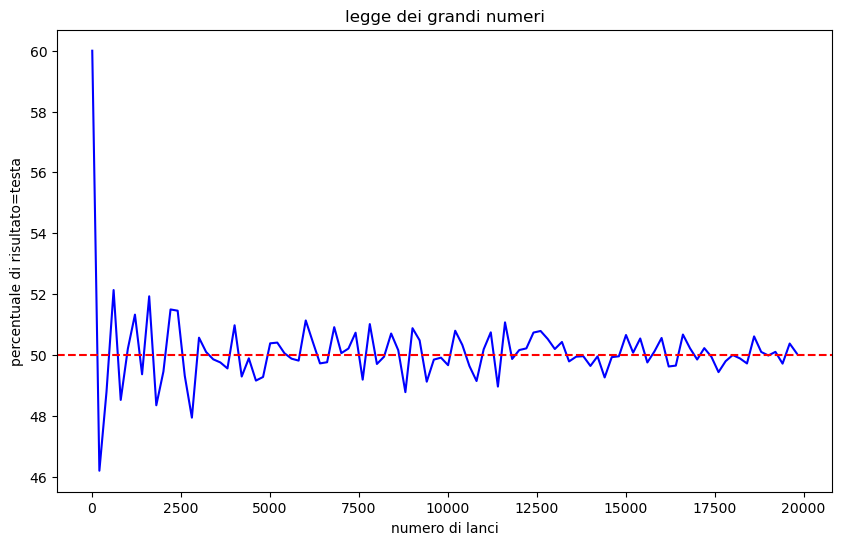

In [4]:

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x=df[0], y=df[1], color="blue")
plt.axhline(50, color='red', linestyle='--')
plt.xlabel("numero di lanci")
plt.ylabel("percentuale di risultato=testa")
plt.title("legge dei grandi numeri")
plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [36]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [34]:
df.isna().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [51]:
# x = df.sort_values(by= 'Embarked', ascending= False)['Embarked'].value_counts().first_valid_index()
x = df['Embarked'].mode()[0]
x 

df['Embarked'] = df['Embarked'].fillna(x)

df['Embarked'].isna().sum()

np.int64(0)

In [53]:
df.duplicated().sum()

np.int64(0)

In [76]:
df.head(10)
df['Age'].describe()

medio = df.groupby('Pclass')['Age'].mean()
medio

md = df['Age'].mean()

df['Age'] = df['Age'].fillna(md)
df

df['Age'].isna().sum()


np.int64(0)

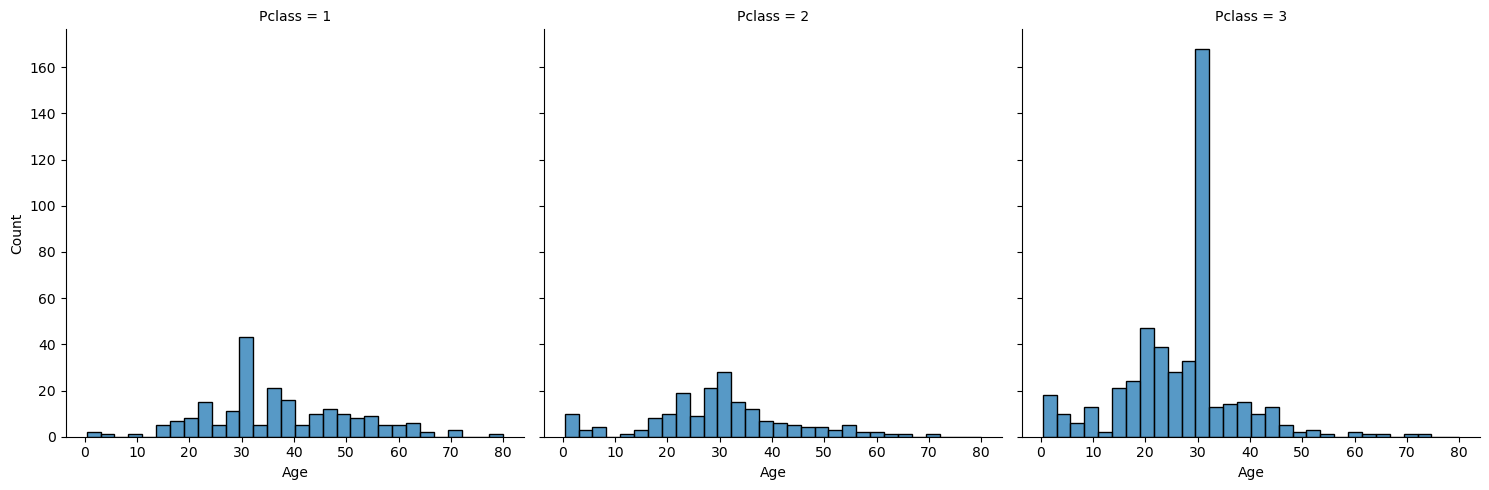

In [81]:
sns.displot(data=df, x='Age', col='Pclass', kind='hist')

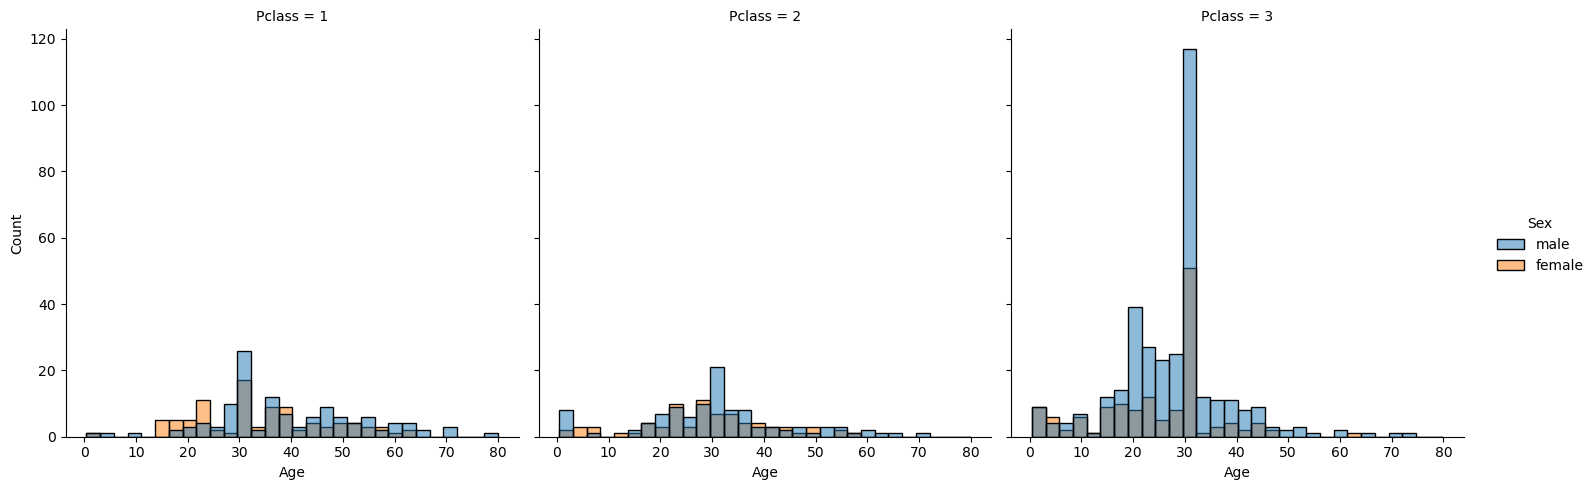

In [82]:
sns.displot(data=df, x='Age', hue='Sex', col='Pclass', kind='hist')

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

df['species'].count()

np.int64(150)

<class 'pandas.Series'>
RangeIndex: 150 entries, 0 to 149
Series name: area
Non-Null Count  Dtype  
--------------  -----  
150 non-null    float64
dtypes: float64(1)
memory usage: 1.3 KB


<Axes: title={'center': 'Dimensioni della larghezza dei petali  per species'}, xlabel='species', ylabel='larghezza petali'>

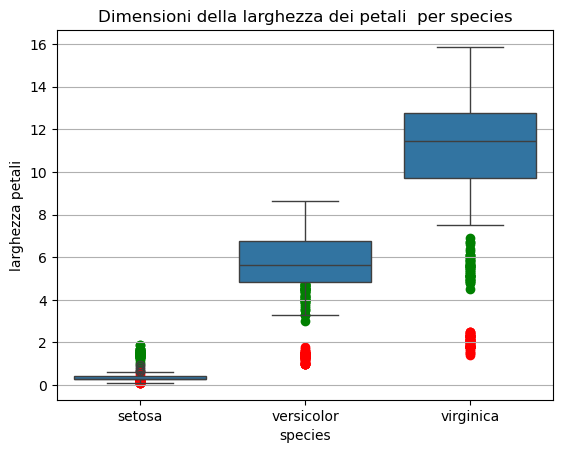

In [101]:
lunghezza = df.groupby('species')['petal_length'].mean()
lunghezza

larghezza = df.groupby('species')['petal_width'].mean()
larghezza

df.head(10)

plt.scatter(df['species'], df['petal_length'], color= 'green')
plt.grid(True)
plt.title("Dimensioni della lunghezza dei petali  per species")
plt.xlabel("species")
plt.ylabel("lunghezza petali")

plt.scatter(df['species'], df['petal_width'], color= 'red')
plt.grid(True)
plt.title("Dimensioni della larghezza dei petali  per species")
plt.xlabel("species")
plt.ylabel("larghezza petali")

df['area'] = df['petal_length'] * df['petal_width']
df['area'].info()
df['area'].describe()

sns.boxplot(data= df, x= 'species', y= 'area')
